In [1]:
import cleanup
import plotting
import stat_analysis
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst

pd.options.mode.use_inf_as_na = True

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_422372\3916186941.py:19: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [2]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [3]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [ ]:
# df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') |
#                               (primary_df_interp['Genotype'] == 'Trh')]
# df_WT_Trh_EA = df_WT_Trh[df_WT_Trh['Odour'] == 'EA']
# df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
# df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1P']

# df_Kir_CSD_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKir') 
#                                  | (primary_df_interp['Genotype'] == 'TrhxKir')
#                                  | (primary_df_interp['Genotype'] == 'CSDxKir')
#                                  | (primary_df_interp['Genotype'] == 'WTxCSD')
#                                  | (primary_df_interp['Genotype'] == 'WTxTrh')]
# df_Kir_CSD_Trh = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Starvation'] == 'Fed')
#                               | (df_Kir_CSD_Trh['Starvation'] == '5h')]
# df_Kir_CSD_Trh_EA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'EA']
# df_Kir_CSD_Trh_PA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'PA']
# df_Kir_CSD_Trh_1P = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == '1P']

# df_Kir_CSD = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Genotype'] == 'WTxCSD')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'WTxKir')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'CSDxKir')]
# df_Kir_CSD_EA = df_Kir_CSD[df_Kir_CSD['Odour'] == 'EA']

# df_TNT_uPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixUPN')]

# df_TNT_MPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixMPN')]

# df_TNT_5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
#                             |    (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

# df_TNT_5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
#                             |   (primary_df_interp['Genotype'] == 'TNTix5HT7')]

In [4]:
# WT and Trh dataframes for PA and 1P 
df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') 
                            | (primary_df_interp['Genotype'] == 'TRH')]


df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1-P']


df_WT_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'WT')]
df_Trh_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'TRH')]

df_WT_PA_104 = df_WT_PA[df_WT_PA['Concentration'] == '10-4']
df_Trh_PA_104 = df_Trh_PA[df_Trh_PA['Concentration'] == '10-4']



df_WT_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'WT')]
df_Trh_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'TRH')]   

df_WT_1P_102 = df_WT_1P[df_WT_1P['Concentration'] == '10-2']
df_Trh_1P_102 = df_Trh_1P[df_Trh_1P['Concentration'] == '10-2']


#Kir crosses for PA and 1P 

df_KirCross = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'TRHxKIR')
                                | (primary_df_interp['Genotype'] == 'CSDxKIR')
                                | (primary_df_interp['Genotype'] == 'WTxCSD')
                                | (primary_df_interp['Genotype'] == 'WTxTRH')]

df_KirCross_PA = df_KirCross[df_KirCross['Odour'] == 'PA']
df_KirCross_1P = df_KirCross[df_KirCross['Odour'] == '1-P']


df_KirCross_PA_CSD = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_PA['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]

df_KirCross_PA_TRH = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_PA['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]


df_KirCross_1P_CSD = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_1P['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]     

df_KirCross_1P_TRH = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_1P['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]



#Concentration validation --> EA

df_KirCross_EA = df_KirCross[df_KirCross['Odour'] == 'EA']

df_KirCross_EA_fed_5h = df_KirCross_EA[(df_KirCross_EA['Starvation'] == 'Fed')
                                      | (df_KirCross_EA['Starvation'] == '5h')]

df_WTxKir_EA_fed_5h = df_KirCross_EA_fed_5h[df_KirCross_EA_fed_5h['Genotype'] == 'WTxKIR']

df_WTxKir_EA_fed_5h_104_105 = df_WTxKir_EA_fed_5h[(df_WTxKir_EA_fed_5h['Concentration'] == '10-4')
                                                    | (df_WTxKir_EA_fed_5h['Concentration'] == '10-5')]



#starvation effects on WT and WTxKir crosses --> EA

df_EA = primary_df_interp[(primary_df_interp['Odour'] == 'EA')]
df_EA_105 = df_EA[(df_EA['Concentration'] == '10-5')]


df_EA_105_starvation = df_EA_105[(df_EA_105['Genotype'] == 'WT')
                             | (df_EA_105['Genotype'] == 'WTxKIR')]


# HT Kir crosses for EA

df_KirCross_HT = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'WTx5HT7')
                                | (primary_df_interp['Genotype'] == 'WTx5HT1A') 
                                | (primary_df_interp['Genotype'] == '5HT7xKIR')
                                | (primary_df_interp['Genotype'] == '5HT1AxKIR')]

df_KirCross_HT_EA = df_KirCross_HT[df_KirCross_HT['Odour'] == 'EA']
df_KirCross_HT_EA_105 = df_KirCross_HT_EA[(df_KirCross_HT_EA['Concentration'] == '10-5')
                                          &((df_KirCross_HT_EA['Starvation'] == 'Fed')
                                            | (df_KirCross_HT_EA['Starvation'] == '5h'))]

df_KirCross_5HT7_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT7')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT7xKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]
df_KirCross_5HT1A_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT1A')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT1AxKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]

# uPN

df_TNTxuPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
                            | (primary_df_interp['Genotype'] == 'TNTixUPN')]

df_TNTxuPN_EA_105 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-5')]

df_TNTxuPN_EA_103 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-3')]

#mPN

df_TNTxMPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
                            | (primary_df_interp['Genotype'] == 'TNTixMPN')]

df_TNTxMPN_EA_105 = df_TNTxMPN[(df_TNTxMPN['Odour'] == 'EA')
                               & (df_TNTxMPN['Concentration'] == '10-5')]

# TNTx5HT7

df_TNTx5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT7')]

df_TNTx5HT7_EA_105 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-5')]

df_TNTx5HT7_EA_103 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-3')]


# TNTx5HT1A
df_TNTx5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

df_TNTx5HT1A_EA_105 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-5')]

df_TNTx5HT1A_EA_103 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-3')] 

 

In [ ]:
# #Replace the RHS with whichever dataframe you would like to plot.

# df_plotter = df_Kir_CSD_EA

# #Comment or uncomment as and when plot is required.

# sbs.lineplot(df_plotter, x = 'Frame', y ='Distance', hue = 'Condition')

# plotting.plot_zone_means_subplot(df_plotter)

# plotting.plot_distance_by_condition(df_plotter)

# plotting.plot_preference_index_over_time(df_plotter)

# for cond in df_plotter['Condition'].unique():
#    plotting.radial_sholl_heatmap_per_bin_normalized(df_plotter[df_plotter['Condition'] == cond], max_radius=11, spatial_bin=2)
#    plotting.plot_trajectory_heatmaps(df_plotter, cond)

# plotting.plot_preference_index_boxplots(df_plotter)

# cumulative_df = plotting.analyze_and_plot_target_acquisition(df_plotter)

# params = plotting.fit_logistic_to_success(cumulative_df)

# params

In [9]:
stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_103[df_TNTx5HT7_EA_103['Frame'] > 400])

▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df         F    PR(>F)
C(Q("Genotype"))                     0.012003   1.0  0.146335  0.704516
C(Q("Starvation"))                   0.262694   1.0  3.202609  0.082702
C(Q("Genotype")):C(Q("Starvation"))  0.042433   1.0  0.517324  0.477048
Residual                             2.706820  33.0       NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.0157

⚠️ Residuals not normal — applied Yeo-Johnson transformation.
▶️ Transformed 2-way ANOVA Results:
                                        sum_sq    df         F    PR(>F)
C(Q("Genotype"))                      0.108274   1.0  0.108616  0.743808
C(Q("Starvation"))                    3.306485   1.0  3.316943  0.077646
C(Q("Genotype")):C(Q("Starvation"))   0.556074   1.0  0.557832  0.460424
Residual                             32.895956  33.0       NaN       NaN

▶️ Shapiro-Wilk p-value for transformed residuals: 0.0432


{'anova_table':                                         sum_sq    df         F    PR(>F)
 C(Q("Genotype"))                      0.108274   1.0  0.108616  0.743808
 C(Q("Starvation"))                    3.306485   1.0  3.316943  0.077646
 C(Q("Genotype")):C(Q("Starvation"))   0.556074   1.0  0.557832  0.460424
 Residual                             32.895956  33.0       NaN       NaN,
 'normality_p': 0.04319320994820493,
 'transformed': True,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x25f259836e0>,
 'simple_effects': {'Genotype_within_Starvation': {'Fed': {'t': -0.7823142448298404,
    'p': 0.4442013657618268},
   '5h': {'t': 0.30035768606304003, 'p': 0.769595626329095}},
  'Starvation_within_Genotype': {'TNTex5HT7': {'t': -0.8988802382322828,
    'p': 0.3805862870679929},
   'TNTix5HT7': {'t': -1.597780006740833, 'p': 0.13833503910908446}}}}

In [10]:
# Replace df_TNTx5HT7_EA_105 with whichever df speed you would like to analyze.

speed_analysis_df = df_TNTx5HT7_EA_103
speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] < 2.0]
speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] > 0.5]

In [11]:
stat_analysis.analyze_two_way_anova(speed_analysis_df, value_col='Speed', trial_averages=True)

▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df          F    PR(>F)
C(Q("Genotype"))                     0.157638   1.0  27.776510  0.000008
C(Q("Starvation"))                   0.000533   1.0   0.093983  0.761100
C(Q("Genotype")):C(Q("Starvation"))  0.004540   1.0   0.799979  0.377577
Residual                             0.187282  33.0        NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.7600


{'anova_table':                                        sum_sq    df          F    PR(>F)
 C(Q("Genotype"))                     0.157638   1.0  27.776510  0.000008
 C(Q("Starvation"))                   0.000533   1.0   0.093983  0.761100
 C(Q("Genotype")):C(Q("Starvation"))  0.004540   1.0   0.799979  0.377577
 Residual                             0.187282  33.0        NaN       NaN,
 'normality_p': 0.7600246845878016,
 'transformed': False,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x25f368e2c30>,
 'simple_effects': {'Genotype_within_Starvation': {'Fed': {'t': -4.164344078516146,
    'p': 0.0005872477058317248},
   '5h': {'t': -3.339313138425122, 'p': 0.004690748040658621}},
  'Starvation_within_Genotype': {'TNTex5HT7': {'t': 0.3738280834188903,
    'p': 0.7129361784419583},
   'TNTix5HT7': {'t': -0.924435059501081, 'p': 0.3699141820319345}}}}

In [14]:
# Replace df with your df for analysis

tukey_result, tukey_summary = stat_analysis.run_tukey_posthoc(
    df=df_TNTx5HT7_EA_103,
    value_col='Speed',
    factor_a='Genotype',
    factor_b='Starvation',
    min_val=0.5,
    max_val=2.0,
    alpha=0.05
)
print(tukey_summary)

          group1         group2  meandiff   p-adj   lower   upper  reject
0   TNTex5HT7_5h  TNTex5HT7_Fed   -0.0127  0.9817 -0.1039  0.0786   False
1   TNTex5HT7_5h   TNTix5HT7_5h    0.1071  0.0333  0.0065  0.2076    True
2   TNTex5HT7_5h  TNTix5HT7_Fed    0.1396  0.0012  0.0483  0.2308    True
3  TNTex5HT7_Fed   TNTix5HT7_5h    0.1197  0.0145  0.0192  0.2203    True
4  TNTex5HT7_Fed  TNTix5HT7_Fed    0.1522  0.0004  0.0610  0.2434    True
5   TNTix5HT7_5h  TNTix5HT7_Fed    0.0325  0.8183 -0.0681  0.1330   False


In [16]:
stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_103[df_TNTx5HT7_EA_103['Frame'] > 400])

▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df         F    PR(>F)
C(Q("Genotype"))                     0.012003   1.0  0.146335  0.704516
C(Q("Starvation"))                   0.262694   1.0  3.202609  0.082702
C(Q("Genotype")):C(Q("Starvation"))  0.042433   1.0  0.517324  0.477048
Residual                             2.706820  33.0       NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.0157

⚠️ Residuals not normal — applied Yeo-Johnson transformation.
▶️ Transformed 2-way ANOVA Results:
                                        sum_sq    df         F    PR(>F)
C(Q("Genotype"))                      0.108274   1.0  0.108616  0.743808
C(Q("Starvation"))                    3.306485   1.0  3.316943  0.077646
C(Q("Genotype")):C(Q("Starvation"))   0.556074   1.0  0.557832  0.460424
Residual                             32.895956  33.0       NaN       NaN

▶️ Shapiro-Wilk p-value for transformed residuals: 0.0432


{'anova_table':                                         sum_sq    df         F    PR(>F)
 C(Q("Genotype"))                      0.108274   1.0  0.108616  0.743808
 C(Q("Starvation"))                    3.306485   1.0  3.316943  0.077646
 C(Q("Genotype")):C(Q("Starvation"))   0.556074   1.0  0.557832  0.460424
 Residual                             32.895956  33.0       NaN       NaN,
 'normality_p': 0.04319320994820493,
 'transformed': True,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x25f334b2de0>,
 'simple_effects': {'Genotype_within_Starvation': {'Fed': {'t': -0.7823142448298404,
    'p': 0.4442013657618268},
   '5h': {'t': 0.30035768606304003, 'p': 0.769595626329095}},
  'Starvation_within_Genotype': {'TNTex5HT7': {'t': -0.8988802382322828,
    'p': 0.3805862870679929},
   'TNTix5HT7': {'t': -1.597780006740833, 'p': 0.13833503910908446}}}}

In [ ]:
df_stats = df_TNTx5HT7_EA_103

df_stats_PI = df_stats[(df_stats['Frame']>400) & (df_stats['Frame']<600) ]
df_stats_speed = df_stats[(df_stats['Speed'] >= 0.5) & (df_stats['Speed'] <= 2)]

# plotting.plot_preference_index_boxplots(df_stats, bin_size=200)
# plotting.plot_preference_index_over_time(df_stats)

stat_analysis.analyze_two_way_anova(
    df_stats_PI,
   factor_a='Genotype',
   factor_b='Starvation',
    value_col='Preference Index',
    alpha=0.05,
    verbose=True,
    trial_averages=True,
    group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
    return_data = True
)



print('-----------------------------------------------------')
stat_analysis.run_tukey_posthoc(
   df_stats_PI,
    'Preference Index',
    'Genotype',
    'Starvation',
    min_val=None,
    max_val=None,
    alpha=0.05,
    trial_averages=True,
    group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
)



▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df         F    PR(>F)
C(Q("Genotype"))                     0.012003   1.0  0.146335  0.704516
C(Q("Starvation"))                   0.262694   1.0  3.202609  0.082702
C(Q("Genotype")):C(Q("Starvation"))  0.042433   1.0  0.517324  0.477048
Residual                             2.706820  33.0       NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.0157

⚠️ Residuals not normal — applied Yeo-Johnson transformation.
▶️ Transformed 2-way ANOVA Results:
                                        sum_sq    df         F    PR(>F)
C(Q("Genotype"))                      0.108274   1.0  0.108616  0.743808
C(Q("Starvation"))                    3.306485   1.0  3.316943  0.077646
C(Q("Genotype")):C(Q("Starvation"))   0.556074   1.0  0.557832  0.460424
Residual                             32.895956  33.0       NaN       NaN

▶️ Shapiro-Wilk p-value for transformed residuals: 0.0432
--------------------------------------

(<statsmodels.sandbox.stats.multicomp.TukeyHSDResults at 0x26096f2f620>,
           group1         group2  meandiff   p-adj   lower   upper  reject
 0   TNTex5HT7_5h  TNTex5HT7_Fed    0.1078  0.8341 -0.2386  0.4543   False
 1   TNTex5HT7_5h   TNTix5HT7_5h   -0.0389  0.9925 -0.4207  0.3429   False
 2   TNTex5HT7_5h  TNTix5HT7_Fed    0.2060  0.3879 -0.1404  0.5525   False
 3  TNTex5HT7_Fed   TNTix5HT7_5h   -0.1467  0.7277 -0.5285  0.2351   False
 4  TNTex5HT7_Fed  TNTix5HT7_Fed    0.0982  0.8688 -0.2483  0.4446   False
 5   TNTix5HT7_5h  TNTix5HT7_Fed    0.2449  0.3223 -0.1369  0.6267   False,
 Group
 TNTex5HT7_5h     0.319855
 TNTex5HT7_Fed    0.427686
 TNTix5HT7_5h     0.280963
 TNTix5HT7_Fed    0.525878
 Name: Preference Index, dtype: float64)

<Axes: xlabel='Condition', ylabel='Preference Index'>

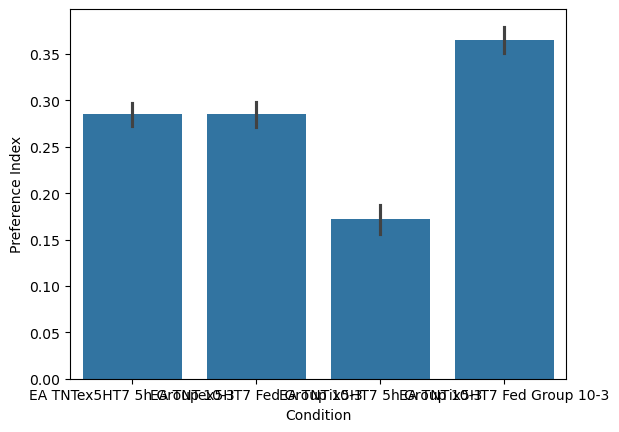

In [24]:
sbs.barplot(data=df_stats_PI[df_stats_PI['Frame'] > 400], x = 'Condition', y='Preference Index')